# Factor Analysis (FA) and Probabilistic PCA

## Real-World Scenario: Inferring Transcription-Factor Activity from Gene Expression

In whole cell modeling, we observe expression for $D$ genes per cell, but the actual *biological* drivers are a much smaller number of **transcription factors (TFs)** that regulate gene programs. Each TF activity $z_\ell$ pushes a *set* of co-regulated genes up or down according to a loading $w_{d\ell}$, and each gene $d$ has its own measurement noise variance $\psi_d$ — pipettes, sequencing depth, and gene-specific biology all differ.

This is exactly **factor analysis**: a Gaussian latent-variable model with diagonal noise. The PCA model from §20.1 is the special case where every gene shares a single noise level $\sigma^2$.

We work through:

1. The **FA generative model** and its low-rank covariance $\mathbf{C} = \mathbf{W}\mathbf{W}^\top + \boldsymbol{\Psi}$
2. **Probabilistic PCA** (PPCA) as a closed-form special case
3. The **EM algorithm** for fitting FA when $\boldsymbol{\Psi}$ is non-isotropic
4. **Posterior over latents** — the probabilistic encoder $p(\mathbf{z}\mid\mathbf{x})$
5. **Unidentifiability** under rotation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal

np.random.seed(0)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML Chapter 20.2

**Generative model** (Eq. 20.36–20.38):

$$p(\mathbf{z}) = \mathcal{N}(\mathbf{z}\mid \mathbf{0}, \mathbf{I}_L), \qquad p(\mathbf{x}\mid \mathbf{z}) = \mathcal{N}(\mathbf{x}\mid \mathbf{W}\mathbf{z} + \boldsymbol{\mu},\, \boldsymbol{\Psi})$$

**Marginal** has low-rank covariance (Eq. 20.39):

$$p(\mathbf{x}) = \mathcal{N}(\mathbf{x}\mid \boldsymbol{\mu},\, \mathbf{C}), \qquad \mathbf{C} = \mathbf{W}\mathbf{W}^\top + \boldsymbol{\Psi}$$

**PPCA**: factor analysis with $\boldsymbol{\Psi} = \sigma^2 \mathbf{I}$ (Eq. 20.42). Closed-form MLE (Eq. 20.45–20.46):

$$\hat{\mathbf{W}} = \mathbf{U}_L (\mathbf{L}_L - \sigma^2 \mathbf{I})^{1/2}, \qquad \hat{\sigma}^2 = \frac{1}{D-L}\sum_{i=L+1}^D \lambda_i$$

**Posterior over latents** (Eq. 20.40):

$$p(\mathbf{z}\mid \mathbf{x}) = \mathcal{N}\!\big(\mathbf{z}\mid \mathbf{W}^\top \mathbf{C}^{-1}(\mathbf{x}-\boldsymbol{\mu}),\; \mathbf{I}_L - \mathbf{W}^\top \mathbf{C}^{-1}\mathbf{W}\big)$$

**EM for FA** (Eq. 20.55–20.60):

$$\boldsymbol{\Sigma}_i = (\mathbf{I}_L + \mathbf{W}^\top \boldsymbol{\Psi}^{-1} \mathbf{W})^{-1}, \qquad \mathbf{m}_i = \boldsymbol{\Sigma}_i \mathbf{W}^\top \boldsymbol{\Psi}^{-1}(\mathbf{x}_i - \boldsymbol{\mu})$$

$$\hat{\tilde{\mathbf{W}}} = \Big[\sum_i \mathbf{x}_i\, \mathbf{b}_i^\top\Big]\Big[\sum_i \mathbf{C}_i\Big]^{-1}, \qquad \hat{\boldsymbol{\Psi}} = \tfrac{1}{N}\,\mathrm{diag}\Big\{\sum_i (\mathbf{x}_i - \hat{\tilde{\mathbf{W}}}\mathbf{b}_i)\,\mathbf{x}_i^\top\Big\}$$

## 1. Synthetic Gene Expression Driven by Three Transcription Factors

We simulate $N = 400$ cells with $D = 20$ genes, generated by $L = 3$ unknown TFs. The trick: we deliberately give different genes very different noise levels — some are clean reporters ($\psi_d$ small), others are noisy ($\psi_d$ large). This is the regime where FA outperforms PPCA, because PPCA can only assume one shared noise.

In [2]:
N = 400
D = 20
L_true = 3
tf_names = ['TF-Growth', 'TF-Stress', 'TF-Cycle']

# True factor loadings W: each TF regulates ~5 partly-overlapping genes
W_true = np.zeros((D, L_true))
W_true[0:6,  0] = np.array([1.5,  1.2,  1.0,  0.8,  0.6, -0.5])
W_true[5:11, 1] = np.array([0.7, -1.4, -1.1, -0.9, -0.6,  0.5])
W_true[10:16, 2] = np.array([0.9,  1.3,  1.0,  0.7, -0.6,  0.4])

# Heteroscedastic per-gene noise (uniqueness)
# - Genes 0-9   : low noise (clean reporters)
# - Genes 10-19 : high noise (noisy genes)
psi_true = np.r_[0.05 * np.ones(10), 0.6 * np.ones(10)]

mu_true = 1.5 + 0.4 * np.random.randn(D)

# Sample latent TF activities and observed expression
Z_true = np.random.randn(N, L_true)
noise = np.random.randn(N, D) * np.sqrt(psi_true)
X = Z_true @ W_true.T + mu_true + noise

print(f'Data: N={N}, D={D}, L_true={L_true}')
print(f'Per-gene uniqueness (\u03c8_d):')
print(f'  clean genes (0-9):  {psi_true[:10].round(2)}')
print(f'  noisy genes (10-19): {psi_true[10:].round(2)}')

Data: N=400, D=20, L_true=3
Per-gene uniqueness (ψ_d):
  clean genes (0-9):  [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05]
  noisy genes (10-19): [0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6]


In [13]:
W_true

array([[ 1.5,  0. ,  0. ],
       [ 1.2,  0. ,  0. ],
       [ 1. ,  0. ,  0. ],
       [ 0.8,  0. ,  0. ],
       [ 0.6,  0. ,  0. ],
       [-0.5,  0.7,  0. ],
       [ 0. , -1.4,  0. ],
       [ 0. , -1.1,  0. ],
       [ 0. , -0.9,  0. ],
       [ 0. , -0.6,  0. ],
       [ 0. ,  0.5,  0.9],
       [ 0. ,  0. ,  1.3],
       [ 0. ,  0. ,  1. ],
       [ 0. ,  0. ,  0.7],
       [ 0. ,  0. , -0.6],
       [ 0. ,  0. ,  0.4],
       [ 0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ]])

## 2. Visualising the FA Generative Process

Reproducing the **"Gaussian spray-can"** intuition of Figure 20.9: an isotropic prior on $\mathbf{z}$ is mapped to an offset $\mathbf{W}\mathbf{z}$ along the latent direction; we then add noise $\mathcal{N}(\mathbf{0}, \boldsymbol{\Psi})$ around each offset.

Crucially, the prior $p(z) = \mathcal{N}(0, 1)$ is **not uniform** — it concentrates around $z = 0$. So sprays near $\boldsymbol{\mu}$ (the image of $z = 0$) are far more frequent than sprays at the tips. The figure below makes this explicit by drawing each spray with opacity proportional to its prior density. The induced marginal is densest exactly where the prior puts most mass — at $\boldsymbol{\mu}$ — and tapers off elliptically along $\mathbf{w}$.

We use $L = 1$ and $D = 2$ for clarity.

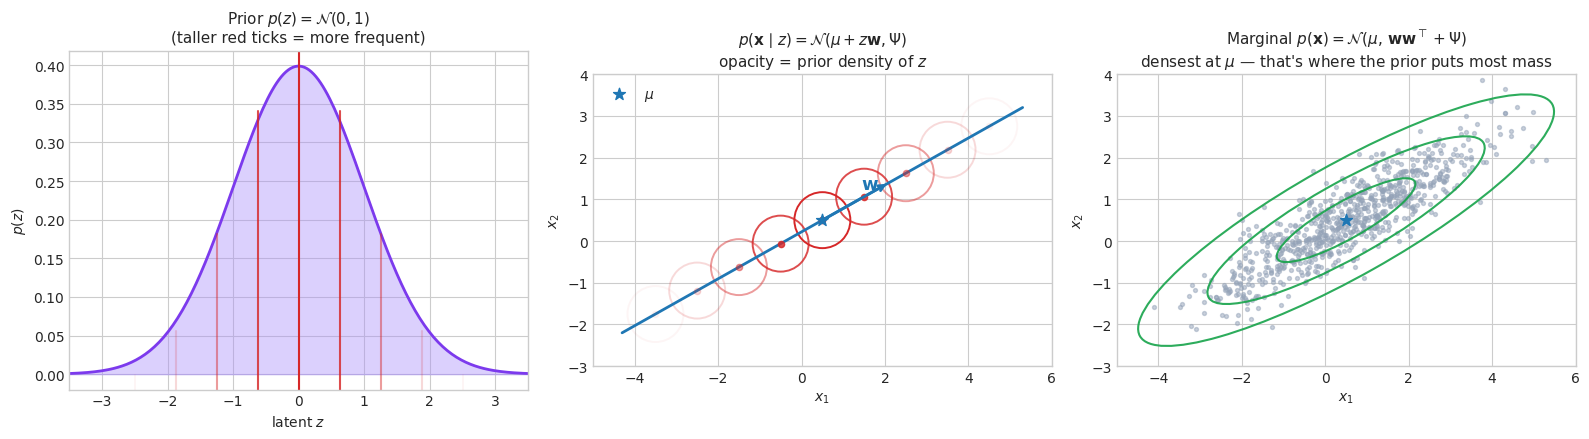

In [3]:
def draw_ellipse(ax, mu, cov, n_std=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)
    e = Ellipse(xy=mu, width=width, height=height, angle=angle, fill=False, **kwargs)
    ax.add_patch(e)

# 1d latent -> 2d observed; isotropic noise for the picture
w_demo = np.array([1.6, 0.9])
mu_demo = np.array([0.5, 0.5])
psi_demo = np.array([[0.2, 0.0], [0.0, 0.2]])
C_demo = np.outer(w_demo, w_demo) + psi_demo

z_grid = np.linspace(-2.5, 2.5, 9)
prior_pdf = np.exp(-0.5 * z_grid**2) / np.sqrt(2*np.pi)   # N(0, 1)
prior_w = prior_pdf / prior_pdf.max()                      # 0..1 weight per spray

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- (0) Latent prior p(z) ---
ax = axes[0]
zs = np.linspace(-3.5, 3.5, 200)
ax.fill_between(zs, np.exp(-0.5*zs**2)/np.sqrt(2*np.pi), color='#a78bfa', alpha=0.4)
ax.plot(zs, np.exp(-0.5*zs**2)/np.sqrt(2*np.pi), color='#7c3aed', lw=2)
for z, alpha in zip(z_grid, prior_w):
    ax.axvline(z, ymin=0, ymax=alpha, color='#d62728', lw=1.5, alpha=alpha)
ax.set_xlabel('latent $z$')
ax.set_ylabel('$p(z)$')
ax.set_title('Prior $p(z) = \\mathcal{N}(0, 1)$\n(taller red ticks = more frequent)', fontsize=11)
ax.set_xlim(-3.5, 3.5)

# --- (1) Spray cans along the axis, weighted by prior ---
ax = axes[1]
for z, alpha in zip(z_grid, prior_w):
    centre = mu_demo + z * w_demo
    draw_ellipse(ax, centre, psi_demo, n_std=1.5,
                 edgecolor='#d62728', alpha=alpha, lw=1.4)
    ax.scatter(*centre, c='#d62728', s=20, alpha=alpha, zorder=3)
ts = np.linspace(-3, 3, 50)
ax.plot(mu_demo[0] + ts * w_demo[0], mu_demo[1] + ts * w_demo[1],
        color='#1f77b4', lw=2)
ax.scatter(*mu_demo, c='#1f77b4', s=80, marker='*', zorder=4, label=r'$\mu$')
ax.annotate('', xy=mu_demo + w_demo, xytext=mu_demo,
            arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=2))
ax.text(*(mu_demo + 0.55 * w_demo + np.array([0.05, 0.25])), r'$\mathbf{w}$',
        color='#1f77b4', fontsize=13)
ax.set_aspect('equal'); ax.set_xlim(-5, 6); ax.set_ylim(-3, 4)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(r'$p(\mathbf{x}\mid z) = \mathcal{N}(\mu + z\mathbf{w}, \Psi)$' +
             '\nopacity = prior density of $z$', fontsize=11)
ax.legend(fontsize=10)

# --- (2) Induced marginal + samples ---
ax = axes[2]
z_samp = np.random.randn(800)
x_samp = mu_demo + z_samp[:, None] * w_demo + \
         np.random.randn(800, 2) @ np.linalg.cholesky(psi_demo).T
ax.scatter(x_samp[:, 0], x_samp[:, 1], s=8, color='#94a3b8', alpha=0.5)
for n in [1, 2, 3]:
    draw_ellipse(ax, mu_demo, C_demo, n_std=n, edgecolor='#16a34a', lw=1.5, alpha=0.9)
ax.scatter(*mu_demo, c='#1f77b4', s=80, marker='*', zorder=4)
ax.set_aspect('equal'); ax.set_xlim(-5, 6); ax.set_ylim(-3, 4)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(r'Marginal $p(\mathbf{x}) = \mathcal{N}(\mu,\, \mathbf{w}\mathbf{w}^\top + \Psi)$' +
             '\ndensest at $\\mu$ — that\'s where the prior puts most mass', fontsize=11)

plt.tight_layout(); plt.show()

## 3. The Low-Rank-Plus-Diagonal Covariance Structure

Equation 20.39 says $\mathbf{C} = \mathbf{W}\mathbf{W}^\top + \boldsymbol{\Psi}$: a $D\times D$ matrix with only $O(LD)$ free parameters instead of $O(D^2)$. Each diagonal element is $\mathbb{V}[x_d] = \sum_\ell w_{d\ell}^2 + \psi_d$ (variance from common factors plus gene-specific *uniqueness*).

Below we visualise this decomposition on the synthetic gene data.

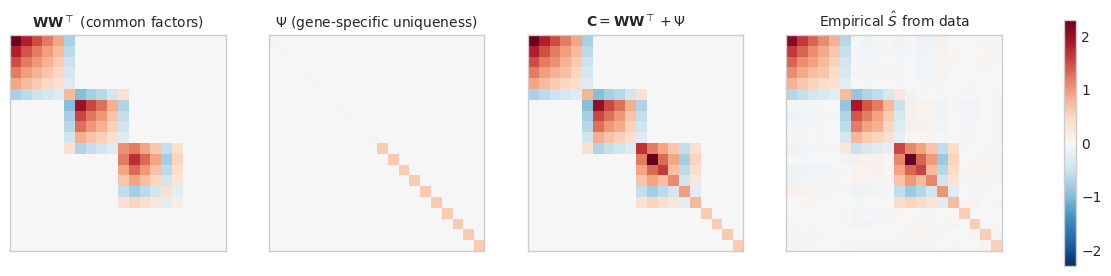

In [4]:
C_true = W_true @ W_true.T + np.diag(psi_true)
S_emp = np.cov(X.T, ddof=0)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
vmax = np.abs(C_true).max()

for ax, M, title in zip(
    axes,
    [W_true @ W_true.T, np.diag(psi_true), C_true, S_emp],
    [r'$\mathbf{W}\mathbf{W}^\top$ (common factors)',
     r'$\Psi$ (gene-specific uniqueness)',
     r'$\mathbf{C} = \mathbf{W}\mathbf{W}^\top + \Psi$',
     r'Empirical $\hat{S}$ from data']):
    im = ax.imshow(M, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

## 4. Probabilistic PCA: A Closed-Form Special Case

When $\boldsymbol{\Psi} = \sigma^2 \mathbf{I}$, the MLE has a closed form (Section 20.2.2). Diagonalise the empirical covariance $\hat{S} = \mathbf{U}\mathbf{L}\mathbf{U}^\top$ and:

$$\hat{\sigma}^2 = \frac{1}{D-L}\sum_{i=L+1}^D \lambda_i, \qquad \hat{\mathbf{W}} = \mathbf{U}_L (\mathbf{L}_L - \hat{\sigma}^2 \mathbf{I})^{1/2}$$

In the noise-free limit $\sigma^2 \to 0$, $\hat{\mathbf{W}}$ becomes proportional to the PCA solution.

In [5]:
def fit_ppca(X, L):
    """Closed-form ML estimate of PPCA (Eq. 20.45-20.46)."""
    N, D = X.shape
    mu = X.mean(0)
    Xc = X - mu
    S = (Xc.T @ Xc) / N
    evals, evecs = np.linalg.eigh(S)
    evals = evals[::-1]
    evecs = evecs[:, ::-1]
    sigma2 = evals[L:].mean()
    W = evecs[:, :L] * np.sqrt(np.maximum(evals[:L] - sigma2, 0.0))
    return mu, W, sigma2

mu_pp, W_pp, sigma2_pp = fit_ppca(X, L=L_true)
C_pp = W_pp @ W_pp.T + sigma2_pp * np.eye(D)

print(f'PPCA fitted \u03c3\u00b2 = {sigma2_pp:.4f}')
print(f'True \u03c8_d range: [{psi_true.min():.2f}, {psi_true.max():.2f}]')
print(f'PPCA \u03c3\u00b2 is just an *average*, blind to the bimodality of true \u03c8.')

PPCA fitted σ² = 0.3220
True ψ_d range: [0.05, 0.60]
PPCA σ² is just an *average*, blind to the bimodality of true ψ.


## 5. EM Algorithm for FA (Section 20.2.3.1)

When $\boldsymbol{\Psi}$ is genuinely heteroscedastic, no closed form exists — we use EM. The implementation follows Eqs. 20.55–20.60, using the augmented variables $\tilde{\mathbf{W}} = (\mathbf{W}, \boldsymbol{\mu})$ and $\tilde{\mathbf{z}} = (\mathbf{z}, 1)$ to update $\mathbf{W}$ and $\boldsymbol{\mu}$ jointly.

**E-step**: posterior moments $p(\mathbf{z}_i \mid \mathbf{x}_i) = \mathcal{N}(\mathbf{m}_i, \boldsymbol{\Sigma}_i)$.

**M-step**: closed-form update of $\tilde{\mathbf{W}}$ and the diagonal of $\boldsymbol{\Psi}$.

We also track the **observed-data log-likelihood** $\sum_i \log \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}, \mathbf{W}\mathbf{W}^\top + \boldsymbol{\Psi})$ to confirm monotonic increase.

In [6]:
def fit_fa_em(X, L, n_iter=80, tol=1e-6, seed=0):
    """EM for factor analysis, joint update of (W, mu) via augmented form."""
    rng = np.random.default_rng(seed)
    N, D = X.shape

    mu = X.mean(0)
    W = 0.1 * rng.standard_normal((D, L))
    psi = X.var(0)  # initialize uniqueness from per-feature variance

    log_liks = []

    for it in range(n_iter):
        # ---- log-likelihood at current parameters ----
        C = W @ W.T + np.diag(psi)
        ll = multivariate_normal.logpdf(X, mean=mu, cov=C, allow_singular=True).sum()
        log_liks.append(ll)

        # ---- E-step ----
        # Sigma_i = (I + W^T psi^-1 W)^{-1}    [shared across i since psi is fixed]
        WtPsiInvW = (W.T / psi) @ W
        Sigma_post = np.linalg.inv(np.eye(L) + WtPsiInvW)
        # m_i = Sigma_post W^T psi^-1 (x_i - mu)
        Xc = X - mu
        m = Xc @ ((W / psi[:, None]) @ Sigma_post)            # (N, L)
        # E[z z^T | x_i] = Sigma_post + m_i m_i^T
        # E[z   | x_i] = m_i

        # ---- M-step (joint update of W and mu via augmented \\tilde W) ----
        # b_i  = [m_i; 1]                                  shape (L+1,)
        # C_i  = [[Sigma_post + m_i m_i^T, m_i], [m_i^T, 1]]
        sum_xb = np.zeros((D, L + 1))
        sum_C = np.zeros((L + 1, L + 1))
        sum_C[:L, :L] = N * Sigma_post + m.T @ m
        sum_C[:L, L] = m.sum(0)
        sum_C[L, :L] = m.sum(0)
        sum_C[L, L] = N
        sum_xb[:, :L] = X.T @ m
        sum_xb[:, L] = X.sum(0)

        W_tilde = sum_xb @ np.linalg.inv(sum_C)
        W_new = W_tilde[:, :L]
        mu_new = W_tilde[:, L]

        # Psi update: Psi = (1/N) diag{ sum_i (x_i - W_tilde b_i) x_i^T }
        residual = X - (m @ W_new.T + mu_new)
        psi_new = (residual * X).sum(0) / N
        psi_new = np.maximum(psi_new, 1e-6)  # numerical floor

        if it > 0 and abs(log_liks[-1] - log_liks[-2]) < tol * abs(log_liks[-2]):
            W, mu, psi = W_new, mu_new, psi_new
            break
        W, mu, psi = W_new, mu_new, psi_new

    return mu, W, psi, np.array(log_liks)

mu_fa, W_fa, psi_fa, ll_curve = fit_fa_em(X, L=L_true, n_iter=120)
C_fa = W_fa @ W_fa.T + np.diag(psi_fa)

print(f'EM converged after {len(ll_curve)} iterations')
print(f'final log-likelihood = {ll_curve[-1]:.2f}')
print(f'log-likelihood gain  = {ll_curve[-1] - ll_curve[0]:.2f}  (must be \u2265 0)')

EM converged after 120 iterations
final log-likelihood = -6465.51
log-likelihood gain  = 4514.20  (must be ≥ 0)


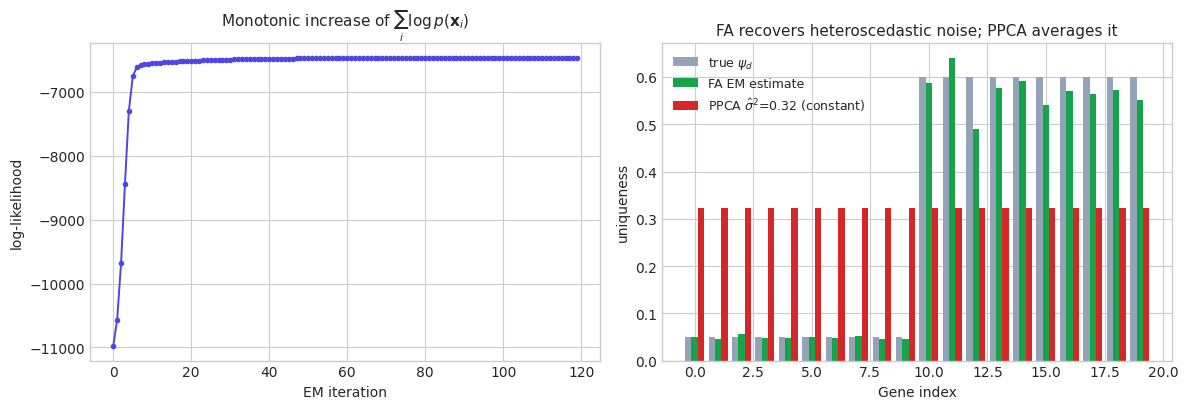

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.plot(ll_curve, '-o', color='#4f46e5', markersize=3, lw=1.4)
ax.set_xlabel('EM iteration')
ax.set_ylabel('log-likelihood')
ax.set_title('Monotonic increase of $\\sum_i \\log p(\\mathbf{x}_i)$', fontsize=11)

ax = axes[1]
idx = np.arange(D)
ax.bar(idx - 0.27, psi_true, width=0.27, color='#94a3b8', label='true $\\psi_d$')
ax.bar(idx,       psi_fa,   width=0.27, color='#16a34a', label='FA EM estimate')
ax.bar(idx + 0.27, [sigma2_pp]*D, width=0.27, color='#d62728',
       label=f'PPCA $\\hat\\sigma^2$={sigma2_pp:.2f} (constant)')
ax.set_xlabel('Gene index')
ax.set_ylabel('uniqueness')
ax.set_title('FA recovers heteroscedastic noise; PPCA averages it', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

## 6. Why FA Wins on Heteroscedastic Data

Both models induce a low-rank-plus-diagonal covariance, but PPCA *requires* the diagonal to be a single scalar $\sigma^2 \mathbf{I}$. We compare:

1. **Held-out log-likelihood**: how well each model explains a fresh batch of cells
2. **Recovery of the true covariance** $\mathbf{C} = \mathbf{W}\mathbf{W}^\top + \boldsymbol{\Psi}$

In [8]:
# Train / test split
n_train = 280
perm = np.random.permutation(N)
tr, te = perm[:n_train], perm[n_train:]

mu_pp_tr, W_pp_tr, sigma2_pp_tr = fit_ppca(X[tr], L=L_true)
C_pp_tr = W_pp_tr @ W_pp_tr.T + sigma2_pp_tr * np.eye(D)

mu_fa_tr, W_fa_tr, psi_fa_tr, _ = fit_fa_em(X[tr], L=L_true, n_iter=200)
C_fa_tr = W_fa_tr @ W_fa_tr.T + np.diag(psi_fa_tr)

# Held-out log-likelihood
ll_test_ppca = multivariate_normal.logpdf(X[te], mean=mu_pp_tr, cov=C_pp_tr).mean()
ll_test_fa = multivariate_normal.logpdf(X[te], mean=mu_fa_tr, cov=C_fa_tr).mean()

# Frobenius distance from true covariance
err_pp = np.linalg.norm(C_pp_tr - C_true, 'fro')
err_fa = np.linalg.norm(C_fa_tr - C_true, 'fro')

print(f'Held-out log-likelihood (per cell):')
print(f'  PPCA: {ll_test_ppca:8.3f}')
print(f'  FA  : {ll_test_fa:8.3f}    (\u0394 = {ll_test_fa - ll_test_ppca:+.3f})')
print(f'\n||C_hat - C_true||_F :')
print(f'  PPCA: {err_pp:.3f}')
print(f'  FA  : {err_fa:.3f}')

Held-out log-likelihood (per cell):
  PPCA:  -21.449
  FA  :  -16.533    (Δ = +4.916)

||C_hat - C_true||_F :
  PPCA: 1.851
  FA  : 1.599


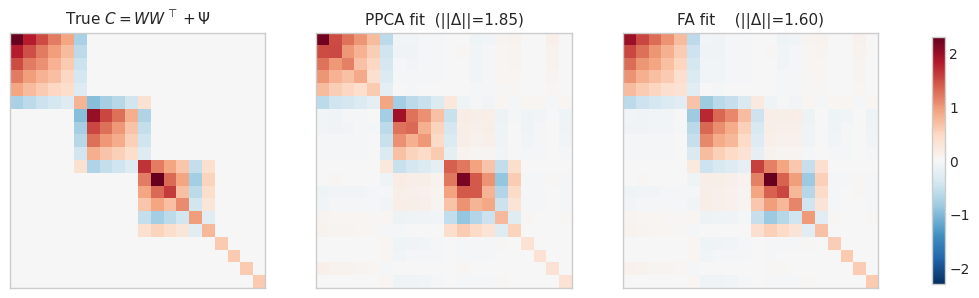

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
vmax = np.abs(C_true).max()
for ax, M, title in zip(
    axes,
    [C_true, C_pp_tr, C_fa_tr],
    ['True $C = WW^\\top + \\Psi$', f'PPCA fit  (||\u0394||={err_pp:.2f})',
     f'FA fit    (||\u0394||={err_fa:.2f})']):
    im = ax.imshow(M, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=11); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

## 7. Probabilistic Encoder: Posterior Over TF Activities

Unlike PCA, FA gives a full Gaussian posterior over the latent factors per cell (Eq. 20.40):

$$p(\mathbf{z}\mid \mathbf{x}) = \mathcal{N}\!\big(\mathbf{W}^\top \mathbf{C}^{-1}(\mathbf{x}-\boldsymbol{\mu}),\; \mathbf{I}_L - \mathbf{W}^\top \mathbf{C}^{-1}\mathbf{W}\big)$$

The posterior **mean** plays the role of an embedding (cf. PCA scores), but the **covariance** quantifies how confident we are about each cell's TF activity — extremely useful in noisy biological data.

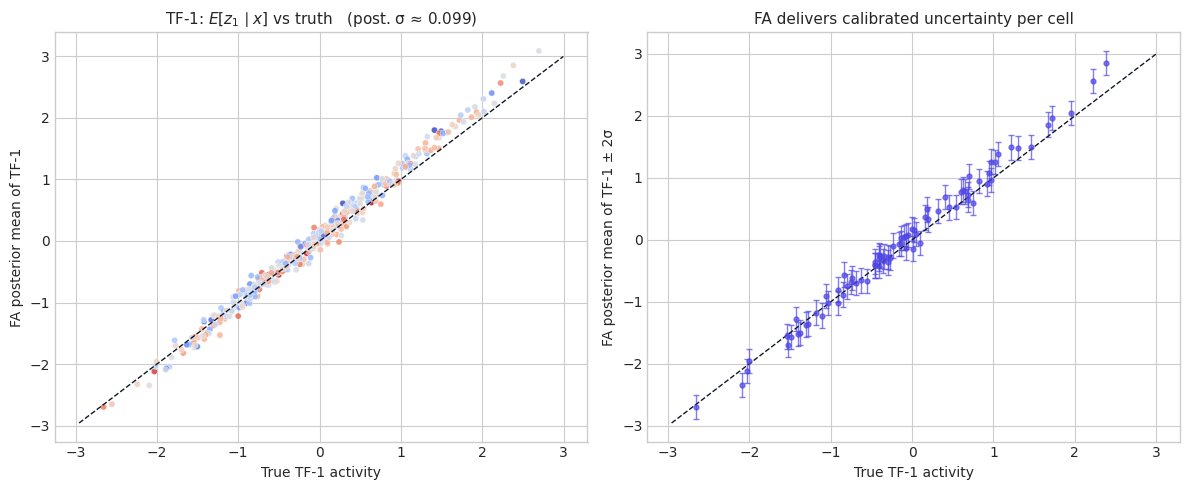

In [10]:
def fa_posterior(X, mu, W, Psi):
    """Returns posterior mean (N, L) and shared covariance (L, L) since Psi is fixed."""
    if Psi.ndim == 1:
        Psi_diag = Psi
    else:
        Psi_diag = np.diag(Psi)
    L = W.shape[1]
    M = np.eye(L) + (W.T / Psi_diag) @ W
    M_inv = np.linalg.inv(M)
    # m_i = (I + W^T Psi^-1 W)^-1 W^T Psi^-1 (x_i - mu)
    Z_mean = (X - mu) @ (W / Psi_diag[:, None]) @ M_inv.T
    Sigma_post = M_inv
    return Z_mean, Sigma_post

Z_post_mean, Sigma_post = fa_posterior(X, mu_fa, W_fa, psi_fa)

# Align FA latent to truth via Procrustes (since FA is rotation-ambiguous, see next section)
U_, _, Vt_ = np.linalg.svd(Z_post_mean.T @ Z_true)
R_align = U_ @ Vt_
Z_aligned = Z_post_mean @ R_align
Sigma_aligned = R_align.T @ Sigma_post @ R_align

# Per-cell posterior std (same for every cell since Psi is fixed)
post_std = np.sqrt(np.diag(Sigma_aligned))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.scatter(Z_true[:, 0], Z_aligned[:, 0], c=Z_true[:, 1], cmap='coolwarm',
           s=20, alpha=0.85, edgecolor='white', linewidth=0.3)
lims = [Z_true[:, 0].min() - 0.3, Z_true[:, 0].max() + 0.3]
ax.plot(lims, lims, ls='--', color='#111827', lw=1)
ax.set_xlabel('True TF-1 activity'); ax.set_ylabel('FA posterior mean of TF-1')
ax.set_title(f'TF-1: $E[z_1\\mid x]$ vs truth   (post. σ ≈ {post_std[0]:.3f})',
             fontsize=11)

ax = axes[1]
# Show predicted means + 2-sigma error bars for a small subset of cells
subset = np.random.choice(N, 80, replace=False)
ax.errorbar(Z_true[subset, 0], Z_aligned[subset, 0], yerr=2 * post_std[0],
            fmt='o', ms=3.5, color='#4f46e5', alpha=0.7, lw=1, capsize=2)
ax.plot(lims, lims, ls='--', color='#111827', lw=1)
ax.set_xlabel('True TF-1 activity'); ax.set_ylabel('FA posterior mean of TF-1 ± 2σ')
ax.set_title('FA delivers calibrated uncertainty per cell', fontsize=11)

plt.tight_layout(); plt.show()

## 8. Unidentifiability: Rotational Ambiguity (Section 20.2.4)

If $\mathbf{R}$ is any orthogonal $L \times L$ matrix, replacing $\mathbf{W}$ with $\mathbf{W}\mathbf{R}$ leaves the marginal $p(\mathbf{x})$ untouched (Eq. 20.66):

$$\mathbf{W}\mathbf{R}\,(\mathbf{W}\mathbf{R})^\top + \boldsymbol{\Psi} = \mathbf{W}\mathbf{R}\mathbf{R}^\top \mathbf{W}^\top + \boldsymbol{\Psi} = \mathbf{W}\mathbf{W}^\top + \boldsymbol{\Psi}$$

So we can recover the *subspace* spanned by the loadings, but not the individual TF axes — they are mixed by an arbitrary rotation. PCA breaks this ambiguity by demanding orthogonal $\mathbf{W}$ and ordering by eigenvalue.

log p(X) with W       = -6465.4891
log p(X) with W · R   = -6465.4891
difference              = -5.46e-12   (numerical noise)

||C(W) - C(WR)||_F = 1.72e-15


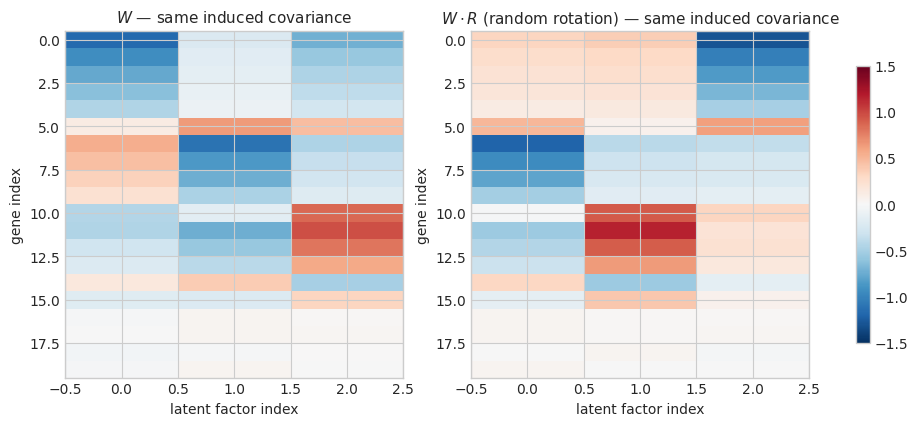

In [11]:
# Pick a random rotation in latent space
Q = np.linalg.qr(np.random.randn(L_true, L_true))[0]
W_rot = W_fa @ Q
C_rot = W_rot @ W_rot.T + np.diag(psi_fa)

ll_orig = multivariate_normal.logpdf(X, mean=mu_fa, cov=C_fa).sum()
ll_rot  = multivariate_normal.logpdf(X, mean=mu_fa, cov=C_rot).sum()

print(f'log p(X) with W       = {ll_orig:.4f}')
print(f'log p(X) with W \u00b7 R   = {ll_rot:.4f}')
print(f'difference              = {ll_orig - ll_rot:.2e}   (numerical noise)')
print(f'\n||C(W) - C(WR)||_F = {np.linalg.norm(C_fa - C_rot, "fro"):.2e}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, Wm, title in zip(axes, [W_fa, W_rot], ['$W$', r'$W \cdot R$ (random rotation)']):
    im = ax.imshow(Wm, cmap='RdBu_r', vmin=-1.5, vmax=1.5, aspect='auto')
    ax.set_title(f'{title} — same induced covariance', fontsize=11)
    ax.set_xlabel('latent factor index'); ax.set_ylabel('gene index')
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

## Summary

- **FA generative model**: $\mathbf{x} = \mathbf{W}\mathbf{z} + \boldsymbol{\mu} + \boldsymbol{\epsilon}$ with $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\Psi})$ for diagonal $\boldsymbol{\Psi}$ — a probabilistic, low-rank-plus-diagonal Gaussian.
- **PPCA** is the special case $\boldsymbol{\Psi} = \sigma^2 \mathbf{I}$, with closed-form MLE in terms of the eigendecomposition of $\hat{S}$.
- **EM for FA** alternates posterior $p(\mathbf{z}\mid \mathbf{x})$ (E-step) with closed-form joint update of $(\mathbf{W}, \boldsymbol{\mu})$ and diagonal $\boldsymbol{\Psi}$ (M-step). Log-likelihood increases monotonically.
- **Heteroscedastic noise pays off**: when genes have very different uniqueness, FA explains held-out data better and recovers the true covariance more accurately than PPCA.
- **Probabilistic encoder**: $p(\mathbf{z}\mid \mathbf{x})$ provides per-cell uncertainty over latent TF activities — something PCA cannot give.
- **Rotational unidentifiability**: $\mathbf{W}$ and $\mathbf{W}\mathbf{R}$ produce identical marginals; we recover the latent subspace, not the axes. To get back identifiable axes we either constrain $\mathbf{W}$ (orthogonal columns as in PCA, lower-triangular form, sparsity priors) or use non-Gaussian latents.

FA is the probabilistic backbone behind mixtures of factor analyzers (§20.2.6), exponential-family PCA for binary/categorical data (§20.2.7), CCA and partial least squares for paired data (§20.2.8) — and the conceptual link to nonlinear factor analysis via VAEs (§20.3.5).

## Appendix: Biology Quick-Start Primer on Transcription Factors

If you came in from the math side, here is just enough cell biology to make the FA model click.

### What is a transcription factor (TF)?

A **transcription factor** is a protein that binds to specific DNA sequences near a gene and either *promotes* or *represses* the transcription of that gene into mRNA. TFs are the cell's regulatory dials: they decide which genes are expressed, when, and how strongly. The human genome encodes about **1,500–1,600 TFs** controlling roughly **20,000 protein-coding genes** — so each TF typically regulates *many* genes (its **regulon**), and each gene is influenced by *several* TFs.

### Why this maps onto factor analysis

| FA symbol | Biological meaning |
|---|---|
| $\mathbf{x} \in \mathbb{R}^D$ | Gene expression profile of one cell — usually $\log$-normalised counts for $D$ genes |
| $\mathbf{z} \in \mathbb{R}^L$ | Latent **TF activities** — abstract regulatory states of the cell |
| $\mathbf{W} \in \mathbb{R}^{D \times L}$ | **Loading / regulon matrix**: $w_{d\ell}$ tells how strongly TF $\ell$ pushes gene $d$ up (positive) or down (negative) |
| $\boldsymbol{\mu} \in \mathbb{R}^D$ | Average expression level of each gene across cells |
| $\boldsymbol{\Psi} = \mathrm{diag}(\psi_d)$ | **Uniqueness**: gene-specific variance not explained by any TF — measurement noise + private biology of gene $d$ |

The generative story reads cleanly: the cell's TF activities $\mathbf{z}$ are drawn from a baseline state $\mathcal{N}(\mathbf{0}, \mathbf{I})$; each TF transmits its activity through its regulon ($\mathbf{W}\mathbf{z}$); the resulting expression is observed on top of the per-gene baseline $\boldsymbol{\mu}$ with gene-specific noise $\boldsymbol{\Psi}$.

### Why noise is genuinely heteroscedastic

Different genes have very different uniqueness, which is exactly why FA is more appropriate than PPCA:

- **Highly expressed, well-measured genes** (housekeeping genes, abundant transcripts) → small $\psi_d$.
- **Low-count genes** suffer from Poisson sampling noise that survives normalisation → large $\psi_d$.
- **Genes regulated by signals not captured in our $L$ TFs** (e.g. circadian effects when we only modelled growth/stress/cycle) → large $\psi_d$.
- **Stochastic transcriptional bursting** is gene-specific — some genes fire in bursts, others in steady streams.

Forcing a single $\sigma^2$ across all genes (PPCA) under-fits the clean genes and over-fits the noisy ones. FA gets this for free.

### What "TF activity" really means

In raw biology, a TF's *activity* depends on its protein concentration, post-translational modifications (phosphorylation, acetylation), nuclear localisation, and co-factor binding — none of which standard RNA-seq sees directly. So we cannot read TF activity off a single gene. **We infer it from the joint behaviour of its regulon**: if all 200 genes downstream of a stress TF are up, the TF is probably active. That inference is precisely the FA posterior $p(\mathbf{z} \mid \mathbf{x})$ we computed in §7. Practical methods used in the field (VIPER, AUCell, decoupleR, SCENIC) are domain-tuned variants of this same idea.

### Why rotational unidentifiability matters in practice

The math (§8) tells us we recover the *subspace* spanned by $\mathbf{W}$ but not the individual axes. Biologically: the data alone cannot tell apart "TF-Growth" from "0.7 × TF-Growth + 0.3 × TF-Cycle" — both fit equally well. To name the latent factors, biologists overlay external knowledge:

- **TF-binding databases** (ChIP-seq, JASPAR, ENCODE) anchor specific columns of $\mathbf{W}$ to known regulons.
- **Sparsity priors** (sparse FA) push each TF to influence only a small set of genes — usually a more interpretable solution.
- **Perturbation experiments** (knock out a TF, measure the response) directly identify its column of $\mathbf{W}$.

So FA provides a principled probabilistic backbone; biology provides the labels.